# Chapter 7 Tutorial: The Method of Least Squares

This notebook turns the main ideas of Chapter 7 into a step-by-step computational tutorial. It follows the chapter's path:

1. weighted averages,
2. least squares for one unknown,
3. simultaneous estimation of several quantities,
4. linear least squares and normal equations,
5. precision of fitted parameters,
6. nonlinear least squares by linearization,
7. the special multiplicative/log-linear case,
8. generalized least-squares adjustment under constraints.

The goal is not only to calculate estimates, but also to see the geometry of the method with graphs.

## Learning goals

By the end, you should be able to:

- explain why more precise observations should receive larger weights;
- show that minimizing a weighted sum of squared residuals gives the weighted average in the one-parameter case;
- build and solve the normal equations for a straight-line model;
- compute residuals, fitted values, estimated error variance, standard errors, and confidence intervals;
- understand how nonlinear least squares is converted into a sequence of linear least-squares corrections;
- adjust observations so that they satisfy an exact condition, such as percentages summing to 100.

## Setup

Run this cell first. The notebook uses only common scientific Python packages.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display, Markdown

pd.set_option("display.precision", 4)
np.set_printoptions(precision=4, suppress=True)

# 1. Why weighted averages?

When repeated measurements have the **same precision**, the ordinary arithmetic average is natural. If the population standard deviation of individual measurements is $\sigma$, the standard error of the average of $N$ independent measurements is

$$
\operatorname{SE}(\bar y)=\frac{\sigma}{\sqrt{N}}.
$$

But Chapter 7 begins with the more general case: several measurements of the same quantity may have **different precisions**. Then the ordinary mean treats weak and strong measurements equally, which is usually not optimal.

For independent measurements $p_1,\ldots,p_n$, with standard deviations $\sigma_1,\ldots,\sigma_n$, define

$$
w_i=\frac{1}{\sigma_i^2}.
$$

The weighted average is

$$
\hat P=\frac{\sum_i w_i p_i}{\sum_i w_i}.
$$

Larger variance means smaller weight; smaller variance means larger weight.

In [2]:
# Example: three measurements of the same circumference-like quantity.
measurements = np.array([31.42, 31.36, 31.50])
sigmas = np.array([0.06, 0.15, 0.10])
weights = 1 / sigmas**2

ordinary_mean = measurements.mean()
weighted_mean = np.sum(weights * measurements) / np.sum(weights)
weighted_se = np.sqrt(1 / np.sum(weights))

summary = pd.DataFrame({
    "measurement": measurements,
    "standard_error_sigma": sigmas,
    "weight_1_over_sigma2": weights,
    "normalized_weight": weights / weights.sum()
}, index=["Method 1", "Method 2", "Method 3"])

display(summary)
print(f"Ordinary mean:  {ordinary_mean:.4f}")
print(f"Weighted mean:  {weighted_mean:.4f}")
print(f"SE of weighted mean, if sigmas are known: {weighted_se:.4f}")

,measurement,standard_error_sigma,weight_1_over_sigma2,normalized_weight
Method 1,31.42,0.06,277.7778,0.6579
Method 2,31.36,0.15,44.4444,0.1053
Method 3,31.50,0.10,100.0000,0.2368


Ordinary mean:  31.4267
Weighted mean:  31.4326
SE of weighted mean, if sigmas are known: 0.0487


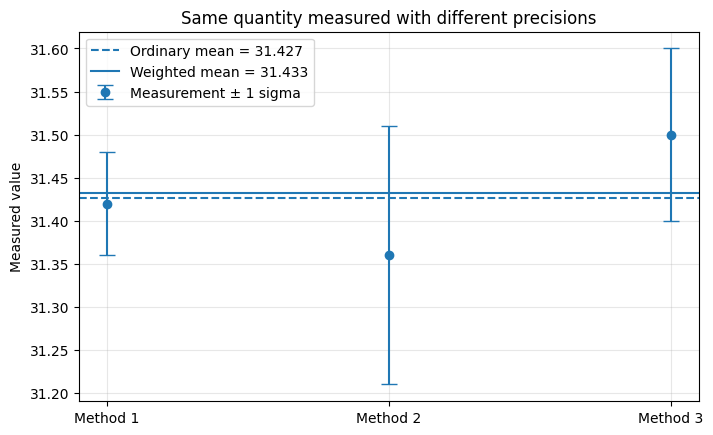

In [3]:
# Graph: measurements with uncertainty bars.
plt.figure(figsize=(8, 4.8))
positions = np.arange(len(measurements))
plt.errorbar(positions, measurements, yerr=sigmas, fmt='o', capsize=6, label='Measurement ± 1 sigma')
plt.axhline(ordinary_mean, linestyle='--', label=f'Ordinary mean = {ordinary_mean:.3f}')
plt.axhline(weighted_mean, linestyle='-', label=f'Weighted mean = {weighted_mean:.3f}')
plt.xticks(positions, summary.index)
plt.ylabel('Measured value')
plt.title('Same quantity measured with different precisions')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

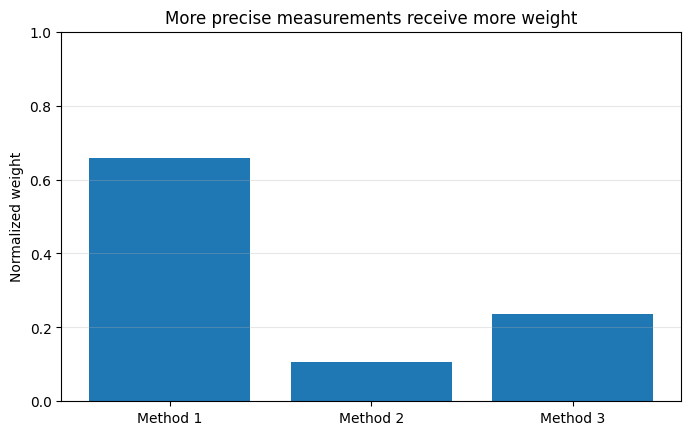

In [4]:
# Graph: each observation's contribution to the weighted average.
plt.figure(figsize=(8, 4.8))
plt.bar(summary.index, weights / weights.sum())
plt.ylabel('Normalized weight')
plt.title('More precise measurements receive more weight')
plt.ylim(0, 1)
plt.grid(True, axis='y', alpha=0.3)
plt.show()

### Interpretation

The measurement with the smallest standard error has the largest weight. The weighted average is pulled toward that measurement because it carries more information about the true value.

A useful result is

$$
\operatorname{Var}(\hat P)=\frac{1}{\sum_i w_i},
\qquad
w(\hat P)=\sum_i w_i.
$$

So, when independent measurements are combined optimally, their **weights add**.

# 2. Least squares for one unknown

The same weighted average can be obtained by minimizing a weighted sum of squared residuals.

Let $P$ be a candidate value for the true quantity. The residual for measurement $p_i$ is

$$
d_i=p_i-P.
$$

The weighted least-squares objective is

$$
S(P)=\sum_i w_i(p_i-P)^2.
$$

The least-squares estimate is the $P$ that makes $S(P)$ as small as possible.

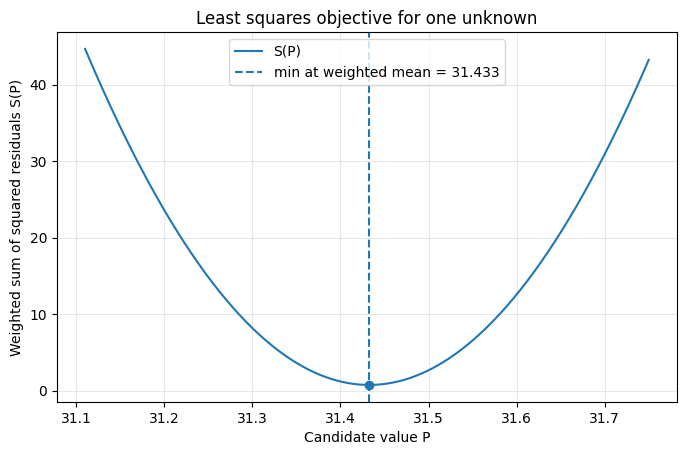

In [5]:
# Evaluate S(P) over a grid.
P_grid = np.linspace(measurements.min() - 0.25, measurements.max() + 0.25, 400)
S_grid = np.array([np.sum(weights * (measurements - P)**2) for P in P_grid])
S_min = np.sum(weights * (measurements - weighted_mean)**2)

plt.figure(figsize=(8, 4.8))
plt.plot(P_grid, S_grid, label='S(P)')
plt.axvline(weighted_mean, linestyle='--', label=f'min at weighted mean = {weighted_mean:.3f}')
plt.scatter([weighted_mean], [S_min], zorder=3)
plt.xlabel('Candidate value P')
plt.ylabel('Weighted sum of squared residuals S(P)')
plt.title('Least squares objective for one unknown')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Algebra check

Differentiate

$$
S(P)=\sum_i w_i(p_i-P)^2
$$

with respect to $P$:

$$
\frac{dS}{dP}=-2\sum_i w_i(p_i-P).
$$

Set this equal to zero:

$$
\sum_i w_i p_i-P\sum_i w_i=0.
$$

Solving gives

$$
\hat P=\frac{\sum_i w_i p_i}{\sum_i w_i}.
$$

So the weighted average is the one-parameter least-squares solution.

# 3. Linear least squares with two unknowns

Chapter 7 then moves from one unknown to several unknowns. The main example is a linear relation between a measured amount of reagent $y$ and a known concentration $x$:

$$
y_i=\alpha+\beta x_i+\varepsilon_i.
$$

Here:

- $\alpha$ is the blank titration, the intercept;
- $\beta$ is the amount of reagent per percent of unknown, the slope;
- $\varepsilon_i$ is random measurement error.

For fitted values

$$
\hat y_i=\hat\alpha+\hat\beta x_i,
$$

the residual is

$$
d_i=y_i-\hat y_i.
$$

The weighted least-squares objective is

$$
S(\alpha,\beta)=\sum_i w_i\left(y_i-\alpha-\beta x_i\right)^2.
$$

## 3.1 Matrix form

Put the model in matrix form:

$$
\mathbf y=X\boldsymbol\theta+\boldsymbol\varepsilon,
\qquad
\boldsymbol\theta=
\begin{bmatrix}
\alpha \\
\beta
\end{bmatrix},
\qquad
X=
\begin{bmatrix}
1 & x_1\\
1 & x_2\\
\vdots & \vdots\\
1 & x_n
\end{bmatrix}.
$$

With diagonal weight matrix $W=\operatorname{diag}(w_1,\ldots,w_n)$, minimize

$$
S=(\mathbf y-X\boldsymbol\theta)^T W (\mathbf y-X\boldsymbol\theta).
$$

The normal equations are

$$
X^T W X\hat{\boldsymbol\theta}=X^T W\mathbf y.
$$

If $X^T W X$ is invertible,

$$
\hat{\boldsymbol\theta}=(X^T W X)^{-1}X^T W\mathbf y.
$$

## 3.2 Chapter 7 numerical example

The data below reproduce the titration example:

| $x$, percent unknown | $y$, reagent | relative weight |
|---:|---:|---:|
| 10 | 33.8 | 1 |
| 20 | 62.2 | 4 |
| 30 | 92.0 | 1 |
| 40 | 122.4 | 1 |

The second observation has weight 4 because it is the average of four titrations, while the others are single titrations.

In [6]:
data = pd.DataFrame({
    "x_percent_unknown": [10, 20, 30, 40],
    "y_reagent": [33.8, 62.2, 92.0, 122.4],
    "relative_weight": [1, 4, 1, 1]
})
display(data)

,x_percent_unknown,y_reagent,relative_weight
0,10,33.8,1
1,20,62.2,4
2,30,92.0,1
3,40,122.4,1


In [7]:
x = data["x_percent_unknown"].to_numpy(dtype=float)
y = data["y_reagent"].to_numpy(dtype=float)
w = data["relative_weight"].to_numpy(dtype=float)

X = np.column_stack([np.ones_like(x), x])
W = np.diag(w)

normal_matrix = X.T @ W @ X
right_hand_side = X.T @ W @ y
theta_hat = np.linalg.solve(normal_matrix, right_hand_side)
alpha_hat, beta_hat = theta_hat

normal_df = pd.DataFrame(normal_matrix, index=["alpha equation", "beta equation"], columns=["alpha coefficient", "beta coefficient"])
rhs_df = pd.DataFrame(right_hand_side, index=["alpha equation", "beta equation"], columns=["right hand side"])

display(Markdown("### Normal-equation matrix"))
display(normal_df)
display(Markdown("### Right-hand side"))
display(rhs_df)

print(f"Estimated alpha/intercept = {alpha_hat:.4f}")
print(f"Estimated beta/slope      = {beta_hat:.4f}")

### Normal-equation matrix

,alpha coefficient,beta coefficient
alpha equation,7.0,160.0
beta equation,160.0,4200.0


### Right-hand side

,right hand side
alpha equation,497.0
beta equation,12970.0


Estimated alpha/intercept = 3.2105
Estimated beta/slope      = 2.9658


These normal equations are

$$
497=7\hat\alpha+160\hat\beta,
$$

$$
12970=160\hat\alpha+4200\hat\beta.
$$

Solving gives approximately

$$
\hat\alpha=3.21,
\qquad
\hat\beta=2.966.
$$

In [8]:
y_hat = X @ theta_hat
residuals = y - y_hat
weighted_squares = w * residuals**2

fit_table = data.copy()
fit_table["fitted_y"] = y_hat
fit_table["residual_d"] = residuals
fit_table["w_d_squared"] = weighted_squares

display(fit_table)
print(f"Weighted sum of squared residuals S = {weighted_squares.sum():.4f}")

,x_percent_unknown,y_reagent,relative_weight,fitted_y,residual_d,w_d_squared
0,10,33.8,1,32.8684,0.9316,0.8678
1,20,62.2,4,62.5263,-0.3263,0.4259
2,30,92.0,1,92.1842,-0.1842,0.0339
3,40,122.4,1,121.8421,0.5579,0.3112


Weighted sum of squared residuals S = 1.6389


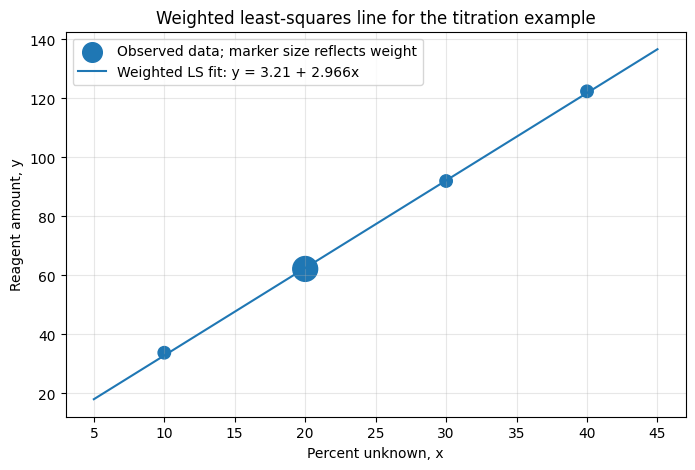

In [9]:
# Graph: weighted fit.
x_line = np.linspace(5, 45, 200)
y_line = alpha_hat + beta_hat * x_line

plt.figure(figsize=(8, 5))
plt.scatter(x, y, s=80 * w, label='Observed data; marker size reflects weight')
plt.plot(x_line, y_line, label=f'Weighted LS fit: y = {alpha_hat:.2f} + {beta_hat:.3f}x')
plt.xlabel('Percent unknown, x')
plt.ylabel('Reagent amount, y')
plt.title('Weighted least-squares line for the titration example')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

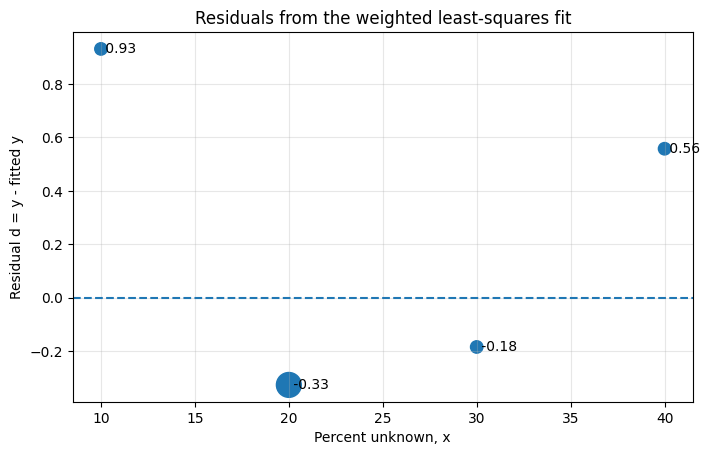

In [10]:
# Graph: residuals.
plt.figure(figsize=(8, 4.8))
plt.axhline(0, linestyle='--')
plt.scatter(x, residuals, s=80 * w)
for xi, ri in zip(x, residuals):
    plt.text(xi, ri, f" {ri:.2f}", va='center')
plt.xlabel('Percent unknown, x')
plt.ylabel('Residual d = y - fitted y')
plt.title('Residuals from the weighted least-squares fit')
plt.grid(True, alpha=0.3)
plt.show()

# 4. Building normal equations by the chapter's “multiplier” method

For each parameter, form a multiplier:

$$
\text{multiplier for parameter }j=(\text{weight})\times(\text{coefficient of parameter }j).
$$

Then multiply every row by that multiplier and add down the columns.

For model $y=\alpha+\beta x$, the coefficients are 1 for $\alpha$ and $x$ for $\beta$.

In [11]:
# Multiplier method for alpha.
alpha_multiplier = w * 1
alpha_table = pd.DataFrame({
    "multiplier_w_times_alpha_coeff": alpha_multiplier,
    "multiplier_times_y": alpha_multiplier * y,
    "multiplier_times_alpha_coeff": alpha_multiplier * 1,
    "multiplier_times_beta_coeff": alpha_multiplier * x,
})
alpha_sums = alpha_table.sum().to_frame("sum").T

display(Markdown("### Alpha normal equation table"))
display(alpha_table)
display(alpha_sums)

# Multiplier method for beta.
beta_multiplier = w * x
beta_table = pd.DataFrame({
    "multiplier_w_times_beta_coeff": beta_multiplier,
    "multiplier_times_y": beta_multiplier * y,
    "multiplier_times_alpha_coeff": beta_multiplier * 1,
    "multiplier_times_beta_coeff": beta_multiplier * x,
})
beta_sums = beta_table.sum().to_frame("sum").T

display(Markdown("### Beta normal equation table"))
display(beta_table)
display(beta_sums)

### Alpha normal equation table

,multiplier_w_times_alpha_coeff,multiplier_times_y,multiplier_times_alpha_coeff,multiplier_times_beta_coeff
0,1.0,33.8,1.0,10.0
1,4.0,248.8,4.0,80.0
2,1.0,92.0,1.0,30.0
3,1.0,122.4,1.0,40.0


,multiplier_w_times_alpha_coeff,multiplier_times_y,multiplier_times_alpha_coeff,multiplier_times_beta_coeff
sum,7.0,497.0,7.0,160.0


### Beta normal equation table

,multiplier_w_times_beta_coeff,multiplier_times_y,multiplier_times_alpha_coeff,multiplier_times_beta_coeff
0,10.0,338.0,10.0,100.0
1,80.0,4976.0,80.0,1600.0
2,30.0,2760.0,30.0,900.0
3,40.0,4896.0,40.0,1600.0


,multiplier_w_times_beta_coeff,multiplier_times_y,multiplier_times_alpha_coeff,multiplier_times_beta_coeff
sum,160.0,12970.0,160.0,4200.0


The sums reproduce the normal equations:

- Alpha equation: $497=7\hat\alpha+160\hat\beta$
- Beta equation: $12970=160\hat\alpha+4200\hat\beta$

This manual method is useful because it shows exactly where each number in the normal equations comes from.

# 5. Precision of the parameter estimates

Finding $\hat\alpha$ and $\hat\beta$ is only part of the solution. Since the observed $y_i$'s contain random errors, the estimates are also random quantities.

If weights are relative weights, the common scale of variance is estimated by

$$
\hat\sigma^2=\frac{\sum_i w_i d_i^2}{N-p},
$$

where:

- $N$ is the number of observations;
- $p$ is the number of estimated parameters;
- $N-p$ is the degrees of freedom;
- $d_i$ are the residuals.

For weighted least squares,

$$
\widehat{\operatorname{Cov}}(\hat{\boldsymbol\theta})
=
\hat\sigma^2(X^T W X)^{-1}.
$$

The square roots of the diagonal elements are the standard errors of $\hat\alpha$ and $\hat\beta$.

In [12]:
N = len(y)
p = X.shape[1]
df = N - p
S = np.sum(w * residuals**2)
sigma2_hat = S / df
cov_theta_hat = sigma2_hat * np.linalg.inv(normal_matrix)
se_theta = np.sqrt(np.diag(cov_theta_hat))

t_crit = stats.t.ppf(0.975, df)
ci_lower = theta_hat - t_crit * se_theta
ci_upper = theta_hat + t_crit * se_theta

precision_table = pd.DataFrame({
    "estimate": theta_hat,
    "standard_error": se_theta,
    "variance_estimate": np.diag(cov_theta_hat),
    "95% CI lower": ci_lower,
    "95% CI upper": ci_upper
}, index=["alpha/intercept", "beta/slope"])

display(precision_table)
print(f"S = {S:.4f}")
print(f"Degrees of freedom N - p = {N} - {p} = {df}")
print(f"Estimated sigma^2 = S / df = {sigma2_hat:.4f}")
print(f"t critical value for 95% CI with {df} df = {t_crit:.4f}")

,estimate,standard_error,variance_estimate,95% CI lower,95% CI upper
alpha/intercept,3.2105,0.9517,0.9057,-0.8843,7.3054
beta/slope,2.9658,0.0389,0.0015,2.7986,3.1330


S = 1.6389
Degrees of freedom N - p = 4 - 2 = 2
Estimated sigma^2 = S / df = 0.8195
t critical value for 95% CI with 2 df = 4.3027


### Why the intervals are wide

Only $N-p=2$ degrees of freedom remain for estimating the error variance. That makes the $t$-critical value large and the confidence intervals wide, especially for the intercept.

This is an important lesson: least squares can give a best fit, but a best fit from very little data may still be very uncertain.

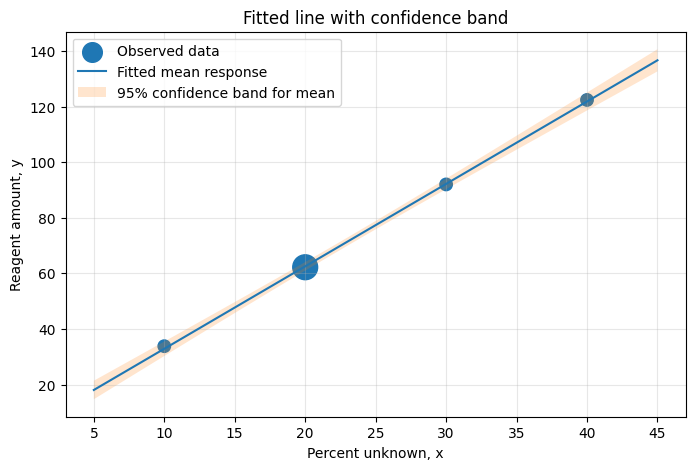

In [13]:
# Confidence band for the fitted mean response.
x_band = np.linspace(5, 45, 200)
X_band = np.column_stack([np.ones_like(x_band), x_band])
y_band = X_band @ theta_hat
se_mean = np.sqrt(np.sum((X_band @ cov_theta_hat) * X_band, axis=1))
margin = t_crit * se_mean

plt.figure(figsize=(8, 5))
plt.scatter(x, y, s=80 * w, label='Observed data')
plt.plot(x_band, y_band, label='Fitted mean response')
plt.fill_between(x_band, y_band - margin, y_band + margin, alpha=0.2, label='95% confidence band for mean')
plt.xlabel('Percent unknown, x')
plt.ylabel('Reagent amount, y')
plt.title('Fitted line with confidence band')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 6. What happens if we ignore weights?

Chapter 7 emphasizes that only the **ratios** of weights matter, but the ratios still matter. If measurements have noticeably different precisions, treating every observation equally can distort both the fitted values and the estimated reliability of the parameters.

,weighted_LS,unweighted_LS,difference_weighted_minus_unweighted
alpha/intercept,3.2105,3.700,-0.4895
beta/slope,2.9658,2.956,0.0098


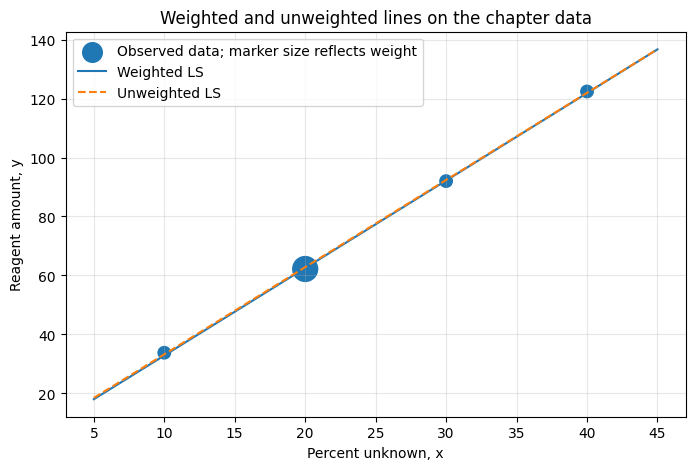

In [14]:
# Compare weighted and unweighted fits on the chapter data.
theta_unweighted = np.linalg.lstsq(X, y, rcond=None)[0]
alpha_ols, beta_ols = theta_unweighted

compare_table = pd.DataFrame({
    "weighted_LS": theta_hat,
    "unweighted_LS": theta_unweighted,
    "difference_weighted_minus_unweighted": theta_hat - theta_unweighted
}, index=["alpha/intercept", "beta/slope"])

display(compare_table)

plt.figure(figsize=(8, 5))
plt.scatter(x, y, s=80 * w, label='Observed data; marker size reflects weight')
plt.plot(x_line, alpha_hat + beta_hat * x_line, label='Weighted LS')
plt.plot(x_line, alpha_ols + beta_ols * x_line, linestyle='--', label='Unweighted LS')
plt.xlabel('Percent unknown, x')
plt.ylabel('Reagent amount, y')
plt.title('Weighted and unweighted lines on the chapter data')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The difference in this small example is modest. To see why weights can matter a lot, the next simulation gives some observations much larger uncertainty than others.

,true,weighted_LS,unweighted_LS
alpha/intercept,4.0,4.0479,5.0094
beta/slope,1.7,1.5666,1.3206


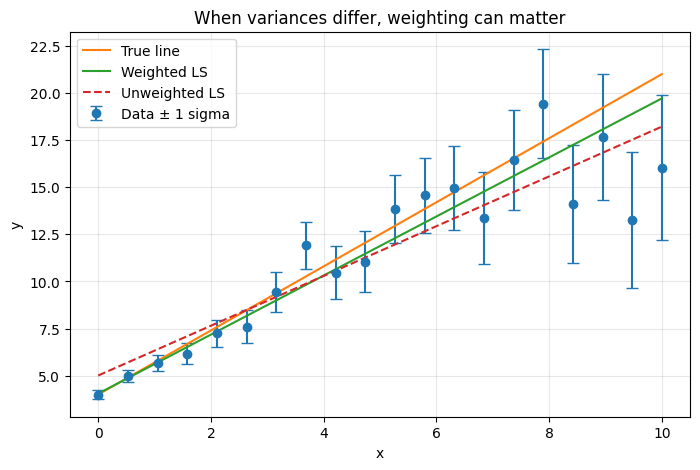

In [15]:
# Simulation with unequal measurement precision.
rng = np.random.default_rng(7)
x_sim = np.linspace(0, 10, 20)
true_alpha, true_beta = 4.0, 1.7
sigma_sim = 0.25 + 0.18 * x_sim**1.3
noise = rng.normal(0, sigma_sim)
y_sim = true_alpha + true_beta * x_sim + noise
w_sim = 1 / sigma_sim**2

X_sim = np.column_stack([np.ones_like(x_sim), x_sim])
theta_w_sim = np.linalg.solve(X_sim.T @ (w_sim[:, None] * X_sim), X_sim.T @ (w_sim * y_sim))
theta_o_sim = np.linalg.lstsq(X_sim, y_sim, rcond=None)[0]

sim_compare = pd.DataFrame({
    "true": [true_alpha, true_beta],
    "weighted_LS": theta_w_sim,
    "unweighted_LS": theta_o_sim
}, index=["alpha/intercept", "beta/slope"])
display(sim_compare)

x_sim_line = np.linspace(x_sim.min(), x_sim.max(), 300)
plt.figure(figsize=(8, 5))
plt.errorbar(x_sim, y_sim, yerr=sigma_sim, fmt='o', capsize=4, label='Data ± 1 sigma')
plt.plot(x_sim_line, true_alpha + true_beta * x_sim_line, label='True line')
plt.plot(x_sim_line, theta_w_sim[0] + theta_w_sim[1] * x_sim_line, label='Weighted LS')
plt.plot(x_sim_line, theta_o_sim[0] + theta_o_sim[1] * x_sim_line, linestyle='--', label='Unweighted LS')
plt.xlabel('x')
plt.ylabel('y')
plt.title('When variances differ, weighting can matter')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 7. Nonlinear least squares by linearization

The earlier sections require equations that are linear in the unknown parameters. Chapter 7 extends the method to nonlinear equations by **linearizing** the nonlinear function around approximate parameter values.

Suppose

$$
y_i=f(x_i;\theta_1,\theta_2)+\varepsilon_i.
$$

Start with an initial guess $\boldsymbol\theta_0$. For a small correction $\Delta\boldsymbol\theta$, use the first-order Taylor approximation

$$
f(x_i;\boldsymbol\theta_0+\Delta\boldsymbol\theta)
\approx
f(x_i;\boldsymbol\theta_0)
+
\sum_j \frac{\partial f(x_i;\boldsymbol\theta)}{\partial \theta_j}\bigg|_{\boldsymbol\theta_0}\Delta\theta_j.
$$

Then solve a linear least-squares problem for the correction $\Delta\boldsymbol\theta$, update the guess, and repeat.

This is the Gauss-Newton idea.

## 7.1 Example: fitting an exponential curve

Let

$$
y=a e^{bx}+\varepsilon.
$$

The model is nonlinear in $b$. Around current values $(a_0,b_0)$:

$$
f(x;a,b)=a e^{bx},
$$

$$
\frac{\partial f}{\partial a}=e^{bx},
\qquad
\frac{\partial f}{\partial b}=a x e^{bx}.
$$

The correction equation is

$$
y_i-f(x_i;a_0,b_0)
\approx
\left(e^{b_0x_i}\right)\Delta a+
\left(a_0x_i e^{b_0x_i}\right)\Delta b+
\varepsilon_i.
$$

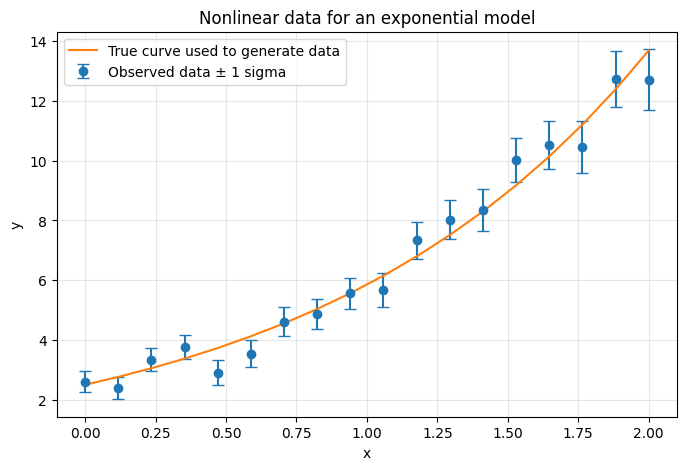

In [16]:
# Generate an exponential data set.
rng = np.random.default_rng(42)
x_nl = np.linspace(0, 2.0, 18)
a_true, b_true = 2.5, 0.85
y_true_nl = a_true * np.exp(b_true * x_nl)
sigma_nl = 0.20 + 0.06 * y_true_nl
y_nl = y_true_nl + rng.normal(0, sigma_nl)
w_nl = 1 / sigma_nl**2

plt.figure(figsize=(8, 5))
plt.errorbar(x_nl, y_nl, yerr=sigma_nl, fmt='o', capsize=4, label='Observed data ± 1 sigma')
plt.plot(x_nl, y_true_nl, label='True curve used to generate data')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Nonlinear data for an exponential model')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [17]:
def exp_model(x, theta):
    a, b = theta
    return a * np.exp(b * x)

def exp_jacobian(x, theta):
    a, b = theta
    exp_bx = np.exp(b * x)
    df_da = exp_bx
    df_db = a * x * exp_bx
    return np.column_stack([df_da, df_db])

def weighted_gauss_newton(x, y, w, theta0, n_iter=8):
    theta = np.array(theta0, dtype=float)
    history = []
    for k in range(n_iter + 1):
        fitted = exp_model(x, theta)
        residual = y - fitted
        objective = np.sum(w * residual**2)
        history.append({"iteration": k, "a": theta[0], "b": theta[1], "objective_S": objective})
        if k == n_iter:
            break
        J = exp_jacobian(x, theta)
        # Solve (J^T W J) delta = J^T W residual
        lhs = J.T @ (w[:, None] * J)
        rhs = J.T @ (w * residual)
        delta = np.linalg.solve(lhs, rhs)
        theta = theta + delta
    return pd.DataFrame(history)

history = weighted_gauss_newton(x_nl, y_nl, w_nl, theta0=[1.0, 0.20], n_iter=8)
display(history)
print("Final estimate:")
print(history.tail(1).to_string(index=False))

,iteration,a,b,objective_S
0,0,1.0000,0.2000,1.3358e+03
1,1,1.9830,3.3202,4.6143e+06
2,2,0.2726,3.2542,5.5472e+04
3,3,0.3012,2.7247,6.6284e+03
4,4,0.6385,1.7291,3.4581e+02
5,5,1.8043,0.6068,4.4669e+02
6,6,2.3596,1.0701,1.8330e+02
7,7,2.4050,0.8994,1.5852e+01
8,8,2.4403,0.8653,1.3411e+01


Final estimate:
 iteration      a      b  objective_S
         8 2.4403 0.8653      13.4115


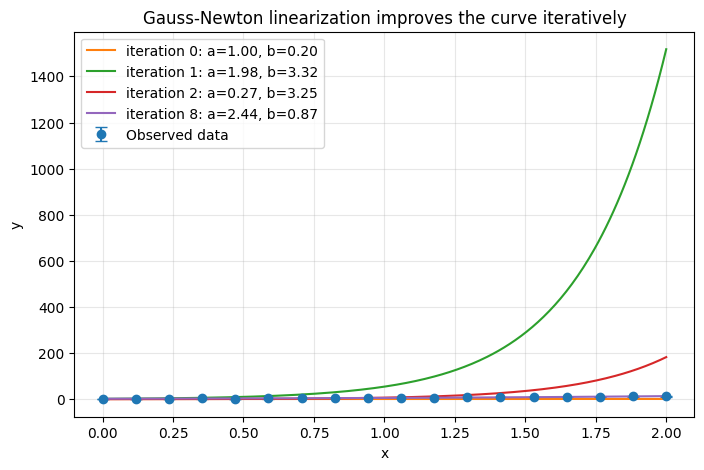

In [18]:
# Graph selected iterations.
x_dense = np.linspace(x_nl.min(), x_nl.max(), 300)

plt.figure(figsize=(8, 5))
plt.errorbar(x_nl, y_nl, yerr=sigma_nl, fmt='o', capsize=4, label='Observed data')
for k in [0, 1, 2, 8]:
    theta_k = history.loc[history["iteration"] == k, ["a", "b"]].to_numpy()[0]
    plt.plot(x_dense, exp_model(x_dense, theta_k), label=f'iteration {k}: a={theta_k[0]:.2f}, b={theta_k[1]:.2f}')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Gauss-Newton linearization improves the curve iteratively')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

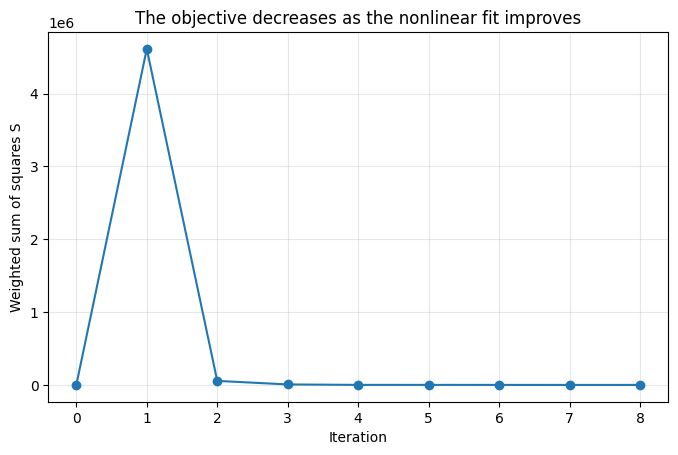

In [19]:
# Graph objective value over iterations.
plt.figure(figsize=(8, 4.8))
plt.plot(history["iteration"], history["objective_S"], marker='o')
plt.xlabel('Iteration')
plt.ylabel('Weighted sum of squares S')
plt.title('The objective decreases as the nonlinear fit improves')
plt.grid(True, alpha=0.3)
plt.show()

### What to notice

- Each iteration solves a **linear** weighted least-squares problem for corrections.
- The fitted curve changes rapidly at first and then stabilizes.
- A poor initial guess can make the linear approximation unreliable. Better starting values usually improve convergence.

# 8. Special multiplicative/log-linear case

Chapter 7 notes an important special case: if the relation is purely multiplicative, involving products, quotients, and powers, logarithms can simplify the linearization.

A simple power-law example is

$$
y=Cx^b.
$$

Taking natural logs gives

$$
\ln y=\ln C+b\ln x.
$$

This is a straight-line regression in log-space:

- response: $\ln y$,
- intercept: $\ln C$,
- slope: $b$,
- predictor: $\ln x$.

This is especially appropriate when errors are approximately **relative** or multiplicative rather than additive on the original scale.

In [20]:
# Power-law data with multiplicative noise.
rng = np.random.default_rng(123)
x_pow = np.linspace(1, 20, 25)
C_true, b_true_power = 1.8, 1.35
relative_sigma = 0.12
# Lognormal multiplicative noise: log(y) has approximately constant variance.
y_pow = C_true * x_pow**b_true_power * np.exp(rng.normal(0, relative_sigma, size=len(x_pow)))

log_x = np.log(x_pow)
log_y = np.log(y_pow)
X_log = np.column_stack([np.ones_like(log_x), log_x])
log_theta = np.linalg.lstsq(X_log, log_y, rcond=None)[0]
log_C_hat, b_hat_power = log_theta
C_hat = np.exp(log_C_hat)

print(f"Estimated C = {C_hat:.4f}")
print(f"Estimated b = {b_hat_power:.4f}")

Estimated C = 1.7509
Estimated b = 1.3722


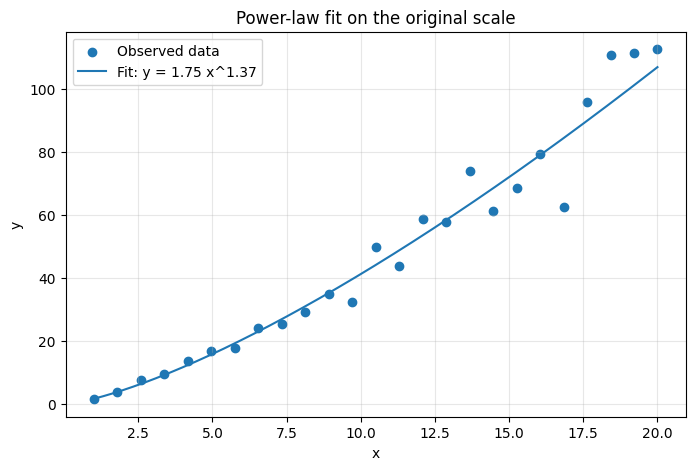

In [21]:
# Original-scale graph.
x_power_dense = np.linspace(x_pow.min(), x_pow.max(), 300)
y_power_fit = C_hat * x_power_dense**b_hat_power

plt.figure(figsize=(8, 5))
plt.scatter(x_pow, y_pow, label='Observed data')
plt.plot(x_power_dense, y_power_fit, label=f'Fit: y = {C_hat:.2f} x^{b_hat_power:.2f}')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Power-law fit on the original scale')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

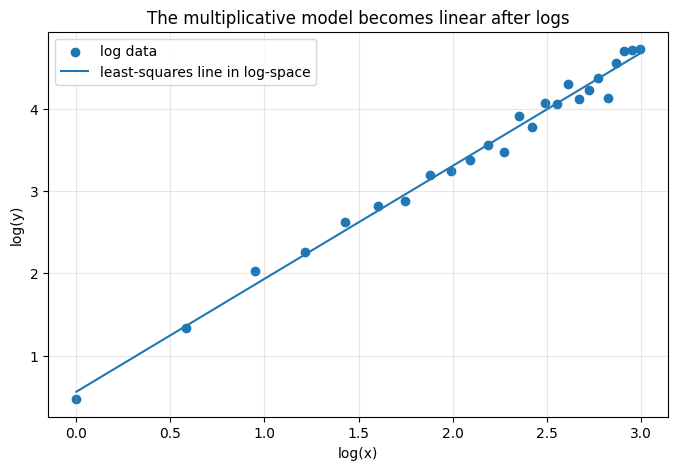

In [22]:
# Log-log graph.
log_y_fit = log_C_hat + b_hat_power * log_x
plt.figure(figsize=(8, 5))
plt.scatter(log_x, log_y, label='log data')
plt.plot(log_x, log_y_fit, label='least-squares line in log-space')
plt.xlabel('log(x)')
plt.ylabel('log(y)')
plt.title('The multiplicative model becomes linear after logs')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Caution about log transformations

A log transform changes the error model. Fitting $\ln y$ by least squares is not the same as fitting $y$ by least squares. It is most natural when the scatter is roughly constant in relative terms, such as a constant percentage error.

# 9. Generalized least-squares adjustment under a constraint

The chapter also discusses adjustment problems: the observed values themselves are adjusted so that they satisfy an exact condition.

Example: an alloy is measured as

- copper: 92.6%, standard error 0.11;
- tin: 5.9%, standard error 0.05;
- antimony: 1.7%, standard error 0.04.

The observed total is 100.2%, but the true percentages must sum to 100%.

Let $z_i$ be adjusted values. Minimize

$$
U=\sum_i \frac{(x_i-z_i)^2}{\sigma_i^2}
$$

subject to

$$
\sum_i z_i=100.
$$

For this one-constraint case, the solution is

$$
z_i=x_i+\sigma_i^2\frac{T-\sum_j x_j}{\sum_j \sigma_j^2},
$$

where $T=100$.

Less precise values get larger corrections because they have larger variance.

In [23]:
components = pd.DataFrame({
    "component": ["Copper", "Tin", "Antimony"],
    "measured_percent": [92.6, 5.9, 1.7],
    "standard_error": [0.11, 0.05, 0.04]
})
components["variance"] = components["standard_error"]**2
T = 100.0
observed_sum = components["measured_percent"].sum()
correction_factor = (T - observed_sum) / components["variance"].sum()
components["correction"] = components["variance"] * correction_factor
components["adjusted_percent"] = components["measured_percent"] + components["correction"]
components["absolute_correction"] = components["correction"].abs()

display(components)
print(f"Observed sum: {observed_sum:.4f}")
print(f"Adjusted sum: {components['adjusted_percent'].sum():.4f}")

,component,measured_percent,standard_error,variance,correction,adjusted_percent,absolute_correction
0,Copper,92.6,0.11,0.0121,-0.1494,92.4506,0.1494
1,Tin,5.9,0.05,0.0025,-0.0309,5.8691,0.0309
2,Antimony,1.7,0.04,0.0016,-0.0198,1.6802,0.0198


Observed sum: 100.2000
Adjusted sum: 100.0000


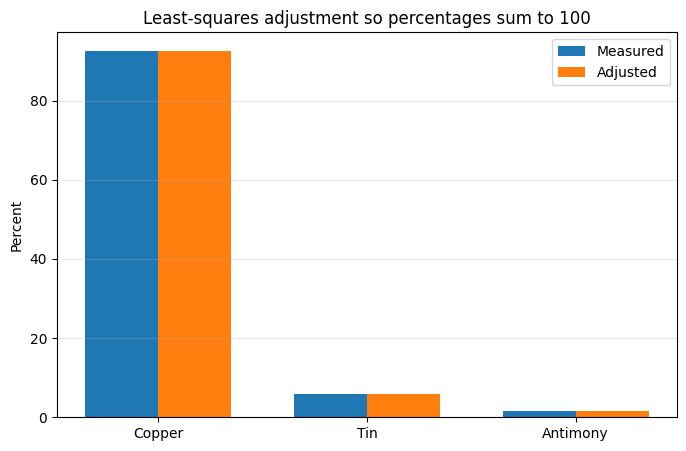

In [24]:
# Graph measured vs adjusted values.
positions = np.arange(len(components))
bar_width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(positions - bar_width/2, components["measured_percent"], width=bar_width, label='Measured')
plt.bar(positions + bar_width/2, components["adjusted_percent"], width=bar_width, label='Adjusted')
plt.xticks(positions, components["component"])
plt.ylabel('Percent')
plt.title('Least-squares adjustment so percentages sum to 100')
plt.legend()
plt.grid(True, axis='y', alpha=0.3)
plt.show()

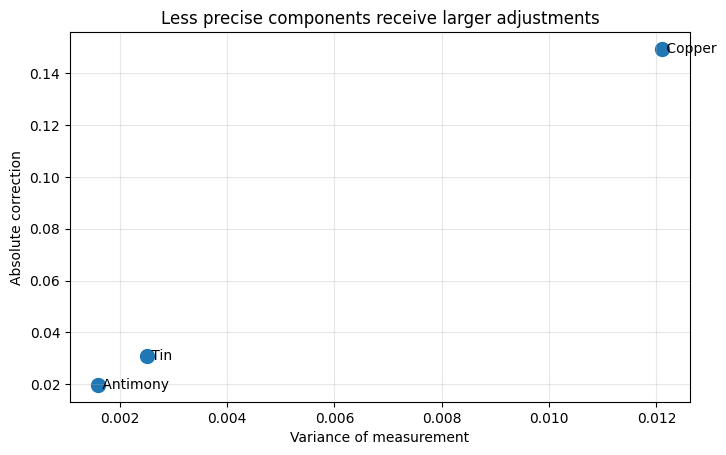

In [25]:
# Graph corrections against variance.
plt.figure(figsize=(8, 4.8))
plt.scatter(components["variance"], components["absolute_correction"], s=100)
for _, row in components.iterrows():
    plt.text(row["variance"], row["absolute_correction"], f" {row['component']}", va='center')
plt.xlabel('Variance of measurement')
plt.ylabel('Absolute correction')
plt.title('Less precise components receive larger adjustments')
plt.grid(True, alpha=0.3)
plt.show()

# 10. Common pitfalls emphasized by Chapter 7

Least squares is powerful, but only under the right assumptions.

### 1. Wrong model

Least squares assumes the mathematical relation is known except for the unknown parameters. If the model is wrong, the fitted parameters may be misleading.

### 2. Correlated errors

The simple formulas here assume independent errors. Correlated errors require modified formulas.

### 3. Wrong or missing weights

Weights should be proportional to reciprocal error variances. If error variances differ substantially and weights are ignored, estimates and uncertainty calculations may be poor.

### 4. Small residuals do not guarantee every parameter is accurate

Least squares chooses a compromise that minimizes overall residual disagreement. A good-looking fit can still have large uncertainty in some parameters, especially when data are few or the design is weak.

# 11. Practice exercises

Try these by editing cells above or writing new code cells.

1. **Weighted average:** Change the standard error of Method 2 from 0.15 to 0.03. How does the weighted average move?
2. **Titration example:** Change the relative weight of the second titration from 4 to 1. What happens to $\hat\alpha$, $\hat\beta$, and the confidence intervals?
3. **Degrees of freedom:** Add more observations to the titration data. How does increasing $N-p$ affect the confidence intervals?
4. **Nonlinear fitting:** Start the exponential example from $(a_0,b_0)=(10,-1)$. Does the method still converge?
5. **Adjustment:** In the alloy example, make copper much less precise by setting its standard error to 0.30. Which component absorbs most of the correction?

# 12. Mini reference: formulas used in this notebook

### Weighted average

$$
\hat P=\frac{\sum_i w_i p_i}{\sum_i w_i},
\qquad
w_i=\frac{1}{\sigma_i^2},
\qquad
\operatorname{Var}(\hat P)=\frac{1}{\sum_i w_i}.
$$

### Weighted linear least squares

$$
\hat{\boldsymbol\theta}=(X^TWX)^{-1}X^TW\mathbf y.
$$

### Residuals

$$
\mathbf d=\mathbf y-X\hat{\boldsymbol\theta}.
$$

### Weighted residual sum of squares

$$
S=\sum_i w_i d_i^2.
$$

### Error-variance estimate with relative weights

$$
\hat\sigma^2=\frac{S}{N-p}.
$$

### Parameter covariance estimate

$$
\widehat{\operatorname{Cov}}(\hat{\boldsymbol\theta})=\hat\sigma^2(X^TWX)^{-1}.
$$

### Approximate confidence interval

$$
\hat\theta_j\pm t_{1-\alpha/2,\,N-p}\operatorname{SE}(\hat\theta_j).
$$

### Linearization for nonlinear least squares

$$
\mathbf y-\mathbf f(\boldsymbol\theta_0)\approx J(\boldsymbol\theta_0)\Delta\boldsymbol\theta+\boldsymbol\varepsilon,
$$

$$
\Delta\hat{\boldsymbol\theta}=(J^TWJ)^{-1}J^TW[\mathbf y-\mathbf f(\boldsymbol\theta_0)].
$$